# Assignment 10

Laplace's equation is a second-order partial-differential equation that can be used to describe many phenomenon in science and engineering.  In two-dimensions it has the homogeneous form

$$
\frac{\partial^2 u(x,y)}{\partial x^2} + \frac{\partial^2 u(x,y)}{\partial y^2} = 0.
$$
    
Physically, this might represent a steady state heat conduction or pressure diffusivity problem.   You can use iterative procedure with a finite difference scheme to arrive at the steady-state solution.  I have implemented such a solver in the file [laplace.py](laplace.py).  To run this code we first import the `LaplaceSolver` class  

In [1]:
from laplace import LaplaceSolver

Now we can instantiate the class, creating the `solver` object and apply some boundary conditions.  In this case, we are applying a constant value $u(x,0) = u(x,1) = 10$.

In [2]:
solver = LaplaceSolver(nx=10, ny=10, xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0)
solver.set_boundary_condtion(side='top', boundary_condition_function=lambda x,y: 10)
solver.set_boundary_condtion('bottom', lambda x,y: 10)

Now we can solve the problem.  Here we use the ipython magic command `%prun` to run the code in a profiler.

In [3]:
%prun solver.solve()

Solution converged in 288 iterations.
 

         328 function calls in 0.056 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      289    0.055    0.000    0.055    0.000 laplace.py:49(iterate)
        1    0.000    0.000    0.056    0.056 laplace.py:78(solve)
        1    0.000    0.000    0.056    0.056 {built-in method builtins.exec}
        3    0.000    0.000    0.000    0.000 socket.py:342(send)
        3    0.000    0.000    0.000    0.000 iostream.py:197(schedule)
        2    0.000    0.000    0.000    0.000 iostream.py:384(write)
        1    0.000    0.000    0.000    0.000 {built-in method builtins.print}
        3    0.000    0.000    0.000    0.000 threading.py:1017(_wait_for_tstate_lock)
        2    0.000    0.000    0.000    0.000 iostream.py:322(_schedule_flush)
        3    0.000    0.000    0.000    0.000 threading.py:1071(is_alive)
        2    0.000    0.000    0.000    0.000 iostream.py:309(_is_master_process)
        3    0.000    0.000   

What the output of the profiler above shows is that the function `iterate()` defined in `laplace.py` is the most expensive part of the code.  Therefore, if we want to speed this code up, we should first focus our efforts on this function.

Just for completeness, I have plotted the solution below.

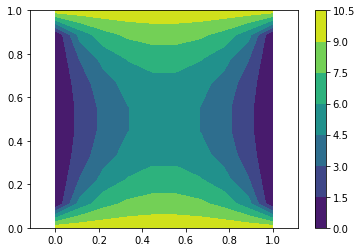

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(solver.xmin, solver.xmax, solver.nx)
y = np.linspace(solver.ymin, solver.ymax, solver.ny)

X, Y = np.meshgrid(x, y)

plt.contourf(X, Y, solver.get_solution())
plt.axis('equal')
plt.colorbar();

Implement a new class member function called `numba_solve()` that uses Numba to speed up the code.  Implement it a way that the existing `solve()` function still works as currently implemented so that timing comparisons can be made.  It is an expectation that the "Numbafied" version of the code should be *at least* 10 times faster.  You can test the timing of the two functions below.

In [5]:
# solver.reset()
# solver.set_boundary_condtion(side='top', boundary_condition_function=lambda x,y: 9)
# solver.set_boundary_condtion('bottom', lambda x,y: 10)
# %timeit solver.solve(quiet=True)

In [6]:
# solver.reset()
# solver.set_boundary_condtion(side='top', boundary_condition_function=lambda x,y: 9)
# solver.set_boundary_condtion('bottom', lambda x,y: 10)
# %timeit solver.numba_solve(quiet=True)